The first step is to create the structure we use to define the network.

As given the network must contain 200 nodes/devices broken into 5 distinct categories as follows:

Group A — Client Workstations:     80 nodes  (40%)

Group B — Internal Servers:        40 nodes  (20%)

Group C — Web/Edge Servers:        30 nodes  (15%)

Group D — Routers/Switches:        20 nodes  (10%)

Group E — IoT/Peripheral Devices:  30 nodes  (15%)


In [21]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

NUM_NODES = 200

NUM_CLIENT = 80
INTERNAL_IDX = 120
WEB_IDX = 150
ROUTER_IDX = 170
IOT_IDX = 200

# This is going to be dynamically created
# Starts at node 0 and ends at node NUM_NODES - 1

all_nodes = range(NUM_NODES)

client_group = {} # 0-39%
internal_server_group = {}
web_server_group = {} # 60-74%
router_group = {} # 75-84%
IoT_group = {} # 85-NUM_NODES-1

# Create the networkX graph
# It is an undirected graph
G = nx.Graph()

G.add_nodes_from(all_nodes)

print(G.nodes)


client_group = all_nodes[:NUM_CLIENT]
internal_server_group = all_nodes[NUM_CLIENT:INTERNAL_IDX]
web_server_group = all_nodes[INTERNAL_IDX:WEB_IDX]
router_group = all_nodes[WEB_IDX:ROUTER_IDX]
Iot_group = all_nodes[ROUTER_IDX:IOT_IDX]

for i in Iot_group:
    print(i)




[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199]
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
1

The next step is to begin creating the network topology based on real-word principles.

Currently, we have 200 devices in a network, but they are not connected with edges yet.
They are divided into 5 different categories as lists, each containing the node index for each device in that category.

The idea is to split up each device into its own sub graph of nodes called a "cluster". Each cluster will contain at least one router, one IoT device, and 3 clients. This is the minimum requirement for a cluster initially, **This can and will change later as the graph evolves**. The servers will be separate and not denoted as a cluster, but we will need to designate some routers as they will be on different networks and will need to communicate with other devices.

There will also be a central hub as part of the topology through which all network traffic will flow. It does not need to be a single router, rather it can be a collection of routers organized in a ring topology. The rest of the network can be diverse in topology, but start simple at first.

range(150, 170)
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169


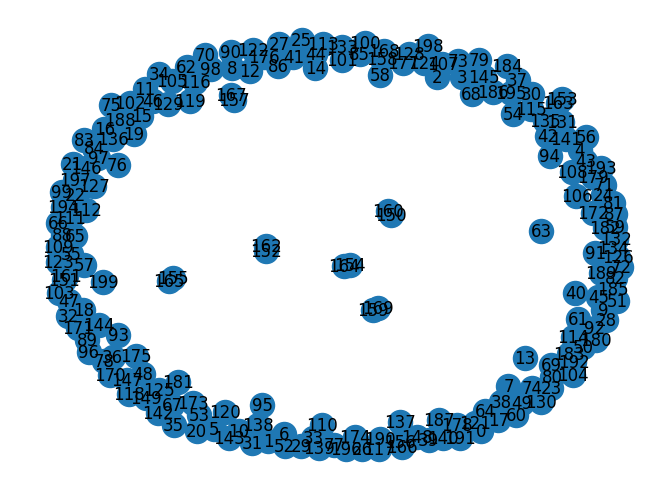

In [44]:
import matplotlib

# Start with the routers and switches

print(router_group)

for i in router_group:
    print(i)

# Split the router group into two groups
# 150-154 <-- Take each index node and pair it with the index+10 node
# 155-159 <-- Same thing here

router_switch_pairs = {(router_group[n], router_group[n+10]) for n in range(int(len(router_group)/2))}


# add these pairs as edges in the graph
G.add_edges_from(router_switch_pairs)

# Draw these in a simple graph

nx.draw_spring(G, with_labels=True)
matplotlib.pyplot.savefig('test.png')
